# Seasonal Agriculture Performance Analysis

### Major Project — Data Analytics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported succesfully")

Libraries imported succesfully


In [2]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Major_Project_Internship/seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Total-Rows :",df.shape[0])
print("Total-Columns :",df.shape[1])


Total-Rows : 4000
Total-Columns : 28


In [5]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [10]:
df['Crop'].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

In [11]:
df['Irrigation_Method'].unique()

array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

In [12]:
df['State'].unique()

array(['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka',
       'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh'], dtype=object)

In [13]:
print("Seasons:")
print(df['Season'].value_counts())

print("\nCrops:")
print(df['Crop'].value_counts())

print("\nIrrigation Methods:")
print(df['Irrigation_Method'].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [14]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df_clean=df.copy()

In [17]:
df_clean.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [18]:
missing=df_clean.isnull().sum()
missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [19]:
missing_summary = pd.DataFrame({
    'Missing Values': df_clean.isnull().sum(),
    'Missing Percentage': (df_clean.isnull().sum() / len(df_clean)) * 100
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


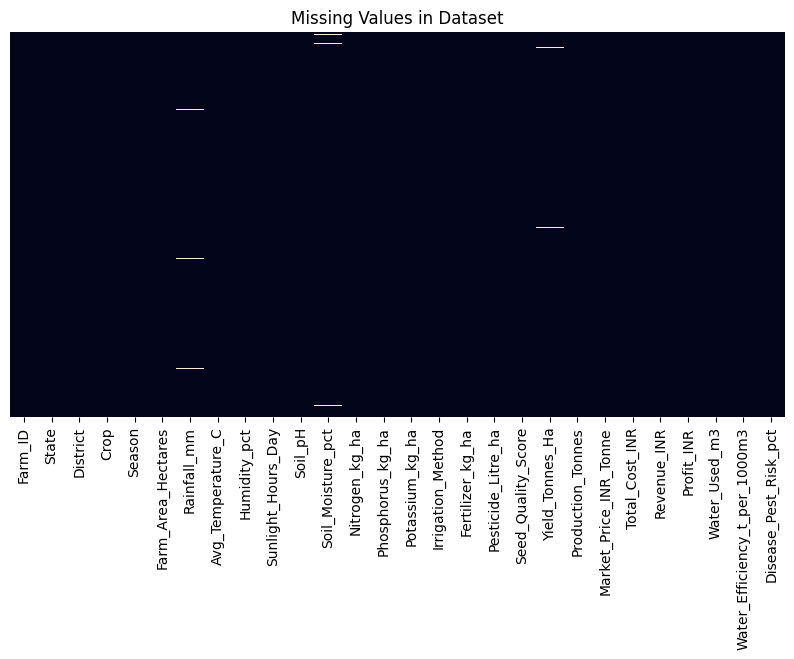

In [20]:
plt.figure(figsize=(10, 5))

sns.heatmap(df_clean.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values in Dataset")
plt.show()

In [21]:
rainfall_median = df_clean['Rainfall_mm'].median()

print("Rainfall Median:", rainfall_median)

Rainfall Median: 582.0


In [22]:
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(rainfall_median)

In [23]:
df_clean['Rainfall_mm'].isnull().sum()

np.int64(0)

In [24]:
Soil_moisture_median = df_clean['Soil_Moisture_pct'].median()

print("Rainfall Median:", Soil_moisture_median)

Rainfall Median: 26.4


In [25]:
df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(Soil_moisture_median)

In [26]:
df_clean['Soil_Moisture_pct'].isnull().sum()

np.int64(0)

In [27]:
df_clean['Yield_Tonnes_Ha'].fillna(df_clean['Yield_Tonnes_Ha'].median())

,Yield_Tonnes_Ha
0,2.46
1,0.30
2,0.52
3,1.84
4,2.21
...,...
3995,0.51
3996,2.75
3997,0.62
3998,1.35


In [28]:
df_clean[['Farm_Area_Hectares',
          'Production_Tonnes',
          'Yield_Tonnes_Ha']].head(10)

,Farm_Area_Hectares,Production_Tonnes,Yield_Tonnes_Ha
0,0.53,1.30,2.46
1,6.53,1.96,0.30
2,4.86,2.53,0.52
3,4.50,8.28,1.84
4,4.21,9.30,2.21
5,5.46,3.93,0.72
6,8.13,20.57,2.53
7,5.34,6.30,1.18
8,6.98,10.68,1.53
9,13.69,31.35,2.29


In [29]:
calculated_yield = (
    df_clean['Production_Tonnes'] /
    df_clean['Farm_Area_Hectares']
)

calculated_yield.head()

,0
0,2.452830
1,0.300153
2,0.520576
3,1.840000
4,2.209026


In [30]:
calculated_yield = (
    df_clean['Production_Tonnes'] /
    df_clean['Farm_Area_Hectares']
)

calculated_yield.head()

,0
0,2.452830
1,0.300153
2,0.520576
3,1.840000
4,2.209026


In [31]:
difference = (
    df_clean['Yield_Tonnes_Ha'] - calculated_yield
)

difference.describe()

,0
count,3968.000000
mean,0.000017
std,0.001070
min,-0.008519
25%,-0.000321
50%,0.000000
75%,0.000313
max,0.010000


In [32]:
valid_rows = df_clean[
    df_clean['Yield_Tonnes_Ha'].notna() &
    df_clean['Production_Tonnes'].notna() &
    df_clean['Farm_Area_Hectares'].notna()
].copy()

valid_rows['Calculated_Yield'] = (
    valid_rows['Production_Tonnes'] /
    valid_rows['Farm_Area_Hectares']
)

valid_rows['Difference'] = (
    valid_rows['Yield_Tonnes_Ha'] -
    valid_rows['Calculated_Yield']
)

valid_rows['Difference'].describe()

,Difference
count,3968.000000
mean,0.000017
std,0.001070
min,-0.008519
25%,-0.000321
50%,0.000000
75%,0.000313
max,0.010000


In [33]:
yield_mask = (
    df_clean['Yield_Tonnes_Ha'].isna() &
    df_clean['Production_Tonnes'].notna() &
    df_clean['Farm_Area_Hectares'].notna()
)

df_clean.loc[yield_mask, 'Yield_Tonnes_Ha'] = (
    df_clean.loc[yield_mask, 'Production_Tonnes'] /
    df_clean.loc[yield_mask, 'Farm_Area_Hectares']
)

In [34]:
df_clean['Yield_Tonnes_Ha'].isnull().sum()

np.int64(0)

In [35]:
df_clean.duplicated().sum()

np.int64(0)

In [36]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [37]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

negative_values = {}

for col in numeric_cols:
    count = (df_clean[col] < 0).sum()
    if count > 0:
        negative_values[col] = count

negative_values

{'Profit_INR': np.int64(1966)}

In [38]:
zero_values = {}

for col in numeric_cols:
    count = (df_clean[col] == 0).sum()
    if count > 0:
        zero_values[col] = count

zero_values

{}

In [39]:
(df_clean['Farm_Area_Hectares'] <= 0).sum()

np.int64(0)

In [40]:
(df_clean['Farm_Area_Hectares'] <= 0).sum()

np.int64(0)

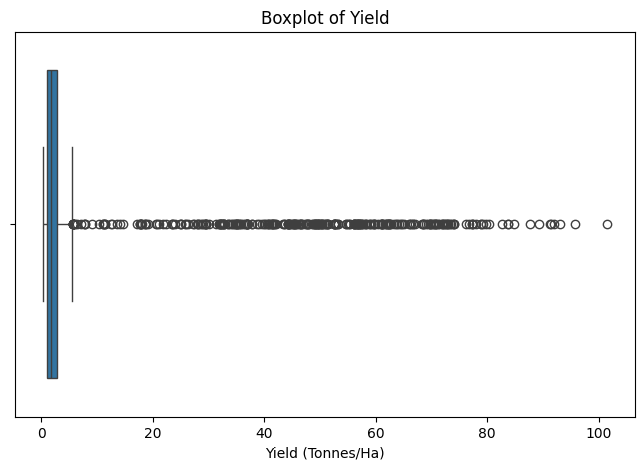

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean['Yield_Tonnes_Ha'])

plt.title("Boxplot of Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.show()

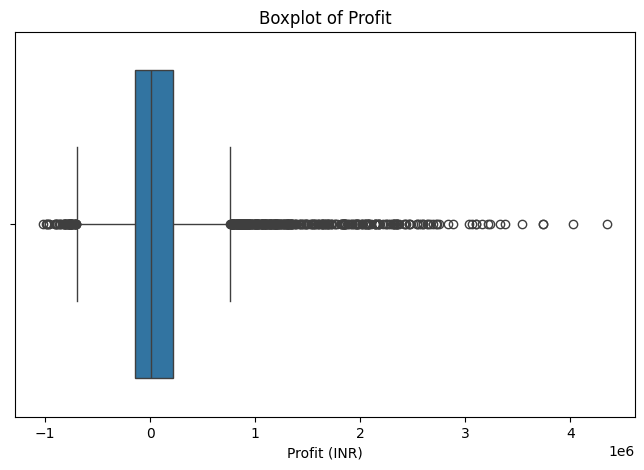

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean['Profit_INR'])

plt.title("Boxplot of Profit")
plt.xlabel("Profit (INR)")
plt.show()

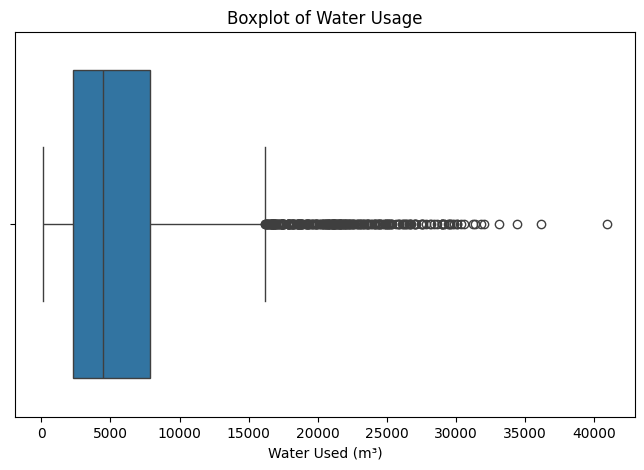

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean['Water_Used_m3'])

plt.title("Boxplot of Water Usage")
plt.xlabel("Water Used (m³)")
plt.show()

In [44]:
df_clean.groupby('Crop')['Yield_Tonnes_Ha'].describe()

,count,mean,std,min,25%,50%,75%,max
Crop,,,,,,,,
Chilli,412.0,1.536409,0.783514,0.300000,0.8675,1.555,2.1025,3.90
Cotton,508.0,1.224471,0.524827,0.299539,0.8500,1.240,1.6000,2.90
Groundnut,424.0,1.318279,0.605088,0.300000,0.8600,1.400,1.7300,3.02
Maize,551.0,2.713176,1.239455,0.300000,1.8300,2.850,3.6500,6.08
Pulses,496.0,0.917032,0.424209,0.298592,0.5700,0.940,1.2400,2.09
Rice,690.0,2.436758,1.150861,0.300000,1.5825,2.460,3.3300,5.70
Sugarcane,305.0,46.925049,21.035083,1.390000,32.6600,48.030,61.9100,101.44
Wheat,614.0,2.107621,0.914317,0.300000,1.4425,2.215,2.7700,4.56


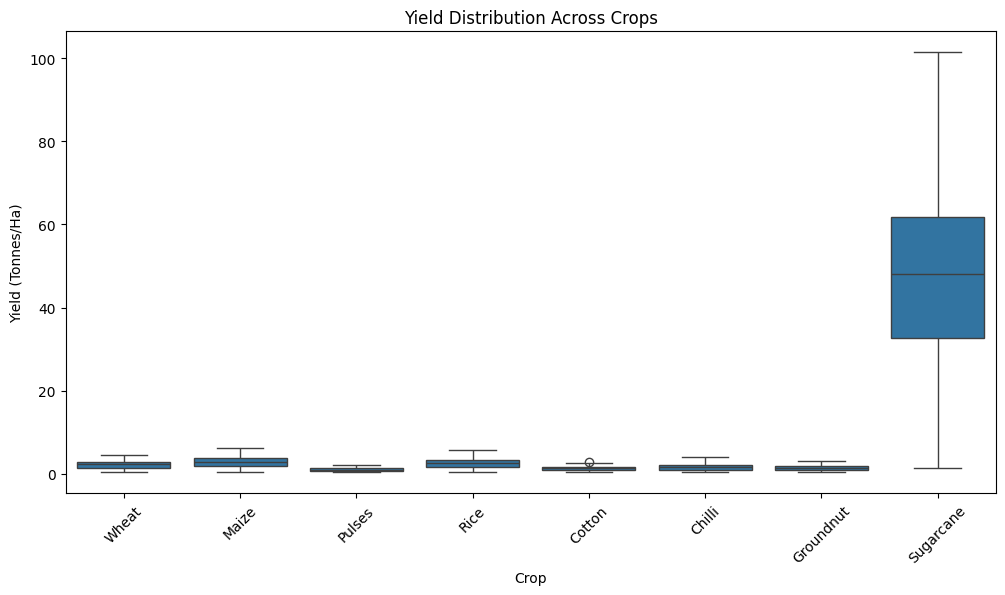

In [45]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x='Crop',
    y='Yield_Tonnes_Ha'
)

plt.xticks(rotation=45)
plt.title("Yield Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [46]:
df_clean.isnull().sum().sum()

np.int64(0)

In [47]:
df_clean.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [48]:
print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

Original Dataset Shape: (4000, 28)
Cleaned Dataset Shape: (4000, 28)


In [50]:
df_clean.to_csv("cleaned_data.csv", index=False)

In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f